In [173]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Transactions.csv')
#Verificação de valores nulos
df.info()

df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   description  50 non-null     object 
 1   value        50 non-null     float64
 2   data         50 non-null     object 
 3   category     50 non-null     object 
 4   type         50 non-null     object 
dtypes: float64(1), object(4)
memory usage: 2.1+ KB


,description,value,data,category,type
0,Gasolina,148.36,03/07/26,Transporte,Pix
1,Reembolso,1670.85,06/07/26,Extra,Receita
2,Freelancer,1633.03,07/07/26,Trabalho,Receita
3,Onibus,379.78,08/07/26,Transporte,Pix
4,Academia,198.52,09/07/26,Saude,Debito


#Analise Mensal

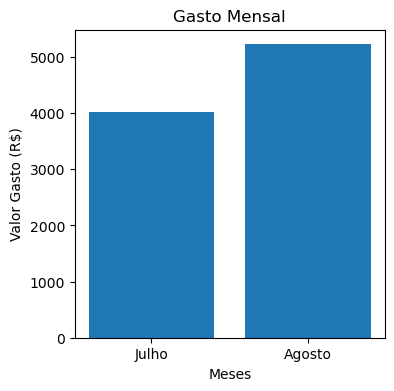

In [174]:
#Transformação da coluna 'data' para um objeto datetime para análises temporais

df_temp = df.copy()

df_temp = df_temp[df_temp['type'] != 'Receita']

df_temp['new_data'] = pd.to_datetime(df_temp['data'], format='%d/%m/%y')
df_temp['month'] = df_temp['new_data'].dt.month

analise_mensal = df_temp.groupby('month')['value'].sum()

plt.figure(figsize=(4,4))
plt.xticks([x for x in range(1, 13)], ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'])
plt.bar(analise_mensal.index, analise_mensal.values)
plt.title("Gasto Mensal")
plt.xlabel("Meses")
plt.ylabel('Valor Gasto (R$)')
plt.show()


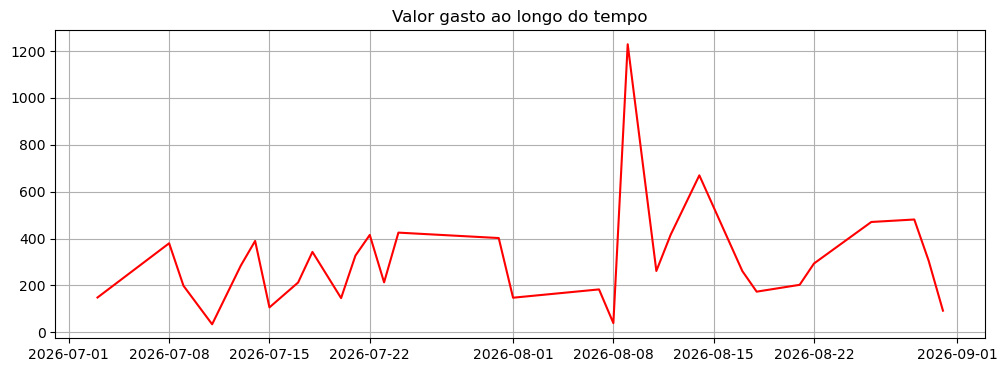

In [175]:
#Análise ao longo do tempo
df_temp = df_temp.sort_values(by=('new_data'))
analise_total_tempo = df_temp.groupby('new_data')['value'].sum()

plt.figure(figsize=(12, 4))
plt.plot(analise_total_tempo.index, analise_total_tempo.values, color='red')
plt.grid()
plt.title('Valor gasto ao longo do tempo')
plt.show()

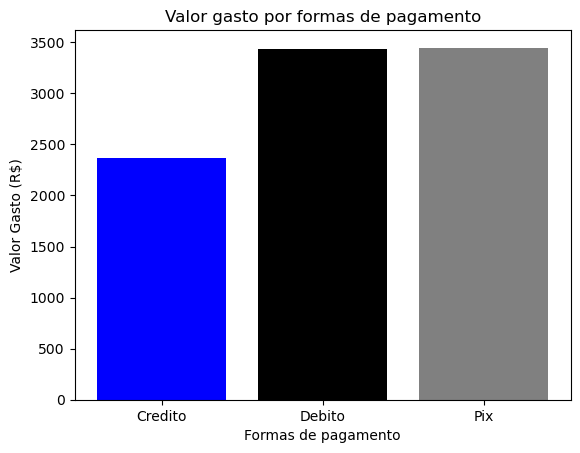

In [176]:
#Forma de pagamento mais usada

pre_soma = df[df['type'] != 'Receita']
soma_despesa = pre_soma.groupby('type')['value'].sum()
soma_despesa
colors = ['blue', 'black', 'gray']
plt.bar(soma_despesa.index, soma_despesa.values, color = colors)
plt.xlabel('Formas de pagamento')
plt.ylabel('Valor Gasto (R$)')
plt.title("Valor gasto por formas de pagamento")
plt.show()

Text(0.5, 1.0, 'Valor gasto por categorias')

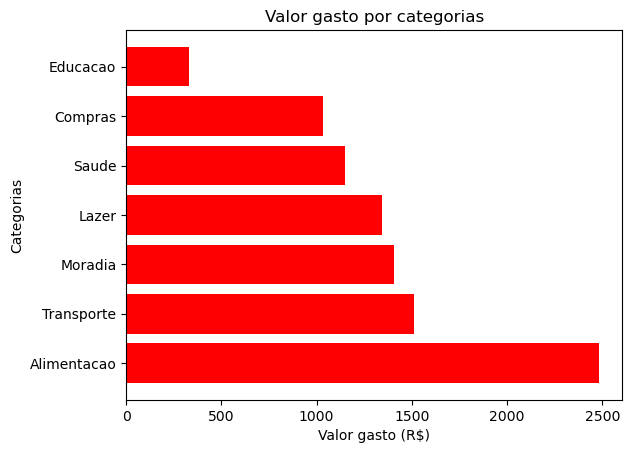

In [177]:
#Categoria com mais gastos

pre_soma = df[df['type'] != 'Receita']
soma_categoria = pre_soma.groupby('category')['value'].sum()
soma_categoria = soma_categoria.sort_values(ascending=False)
soma_categoria

plt.barh(soma_categoria.index, soma_categoria.values, color = 'red')
plt.xlabel("Valor gasto (R$)")
plt.ylabel("Categorias")
plt.title("Valor gasto por categorias")